SIR stands for three groups that every person in a population belongs to at any one point during an outbreak:
    S - Susceptible; people who are yet to be infected but can catch the disease
    I - Infectious; currently sick and can infect others
    R - Recovered; recovered and now have immune.

One may move from S to I then R. The model is meant to track how the size of each group changed week by week.
The graph from Sprint 1 is this mechanism; the peaks indicated the highest number of I and many move to R, the outbreak collapses as no more people can be infected.

Two numbers control everything:
    Beta (β) - transmission rate. High beta means faster virus spread.
        Answers how quickly can S become I.
    
    Gamma (γ) - recovery rate.High gamma, quicker recovery.
        Answers how quickly can I become R.

Fom Gamma and Beta, R₀ is derived, the basic reproduction number:
    R₀ = β / γ

R₀ tells how many people can one infected person infect on average.
    R₀ > 1 = outbreak breaks
    R₀ < 1 = outbreak dies
        
        Seasonal flu tends to have an R₀ between 1.2 - 1.4.
        COVID-19's original strain was 2.5
        Measles is around 15.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.integrate import odeint
from scipy.optimize import minimize

# Loading cleaned data from Sprint 1
df = pd.read_csv('../data/fluwatch_clean.csv', parse_dates = ['date'])

print(f"Loaded {len(df)} weeks of data")
print(f"Data range: {df['date'].min().date()} to {df['date'].max().date()}")
df.head()

Loaded 157 weeks of data
Data range: 2014-09-01 to 2017-08-21


,InfluenzaSeasonandEpidemiologicalWeek,TotalFluTests,PositiveFluAH1N1pdm09,PositiveFluAH3,PositiveFluAunsubtyped,TotalFluBPositive,TotalRSVTests,TotalPositiveRSV,TotalParaTests,TotalPositivePara,...,TotalPositivehMPV,TotalEnteroRhinoTests,TotalPositiveEnteroRhino,TotalCoronaTests,TotalPositiveCorona,season,TotalFluPositive,year,week,date
0,201435,1311.0,0.0,0.0,2.0,3.0,1327.0,5.0,1160.0,23.0,...,1.0,595.0,154.0,1140.0,2.0,2014-2015,5.0,2014,35,2014-09-01
1,201436,1323.0,0.0,1.0,2.0,1.0,1334.0,3.0,1155.0,27.0,...,1.0,621.0,157.0,815.0,2.0,2014-2015,4.0,2014,36,2014-09-08
2,201437,1928.0,2.0,8.0,3.0,2.0,1827.0,9.0,1590.0,37.0,...,0.0,800.0,261.0,1036.0,0.0,2014-2015,15.0,2014,37,2014-09-15
3,201438,2458.0,0.0,10.0,4.0,5.0,2451.0,9.0,2120.0,44.0,...,1.0,1196.0,443.0,1360.0,3.0,2014-2015,19.0,2014,38,2014-09-22
4,201439,2961.0,0.0,16.0,7.0,3.0,2724.0,20.0,2377.0,51.0,...,1.0,1297.0,492.0,1460.0,1.0,2014-2015,26.0,2014,39,2014-09-29


Weeks in 2014 - 2015 season: 53
Peak flu positives: 4433
Peak week: 2015-01-05


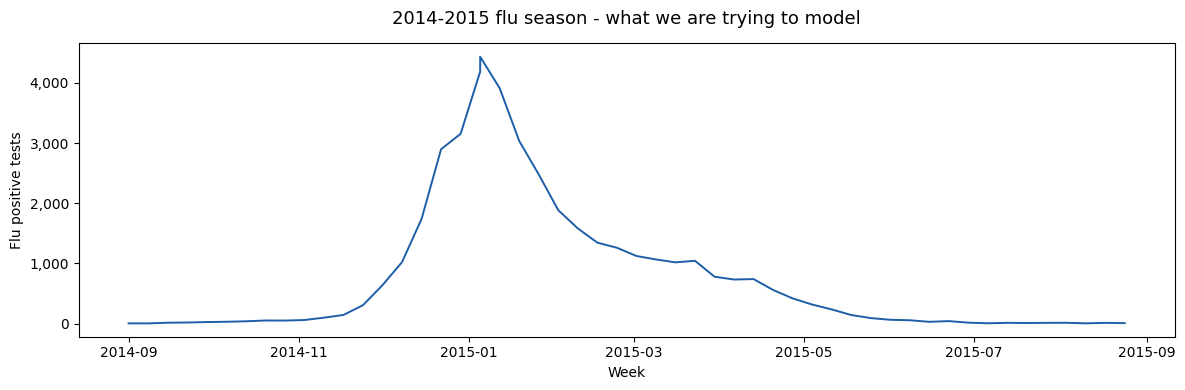

In [21]:
#Isolating the 2014 - 2015 season only
season = df[df['season'] == '2014-2015'].copy()
season = season.sort_values('date').reset_index(drop=True)

print(f"Weeks in 2014 - 2015 season: {len(season)}")
print(f"Peak flu positives: {season['TotalFluPositive'].max():.0f}")
print(f"Peak week: {season.loc[season['TotalFluPositive'].idxmax(), 'date'].date()}")

# Visualizing what is being worked with
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(season['date'], season['TotalFluPositive'],
        color = '#1D5EA8', linewidth = 1.4)

ax.set_title('2014-2015 flu season - what we are trying to model', fontsize = 13, pad = 14)
ax.set_xlabel('Week')
ax.set_ylabel('Flu positive tests')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

plt.tight_layout()
plt.show()

In [22]:
#Defining the SIR model

# Canada's approximate pop. during this period
N = 35_000_000

def sir_model(y, t, beta, gamma):
    """
    The SIR model equations.
    
    y     — current values of [S, I, R]
    t     — current time point
    beta  — transmission rate
    gamma — recovery rate
    """

    S, I, R = y

    # How many new infections happen this time step
    new_infections = beta * S * I / N

    # How many recoveries happen this time step
    new_recoveries = gamma * I

    # Rtae of change for each comparment
    dS = -new_infections
    dI = new_infections - new_recoveries
    dR = new_recoveries

    return [dS, dI, dR]

print("SIR model defined.")
print(f"Population N: {N:,}")

SIR model defined.
Population N: 35,000,000


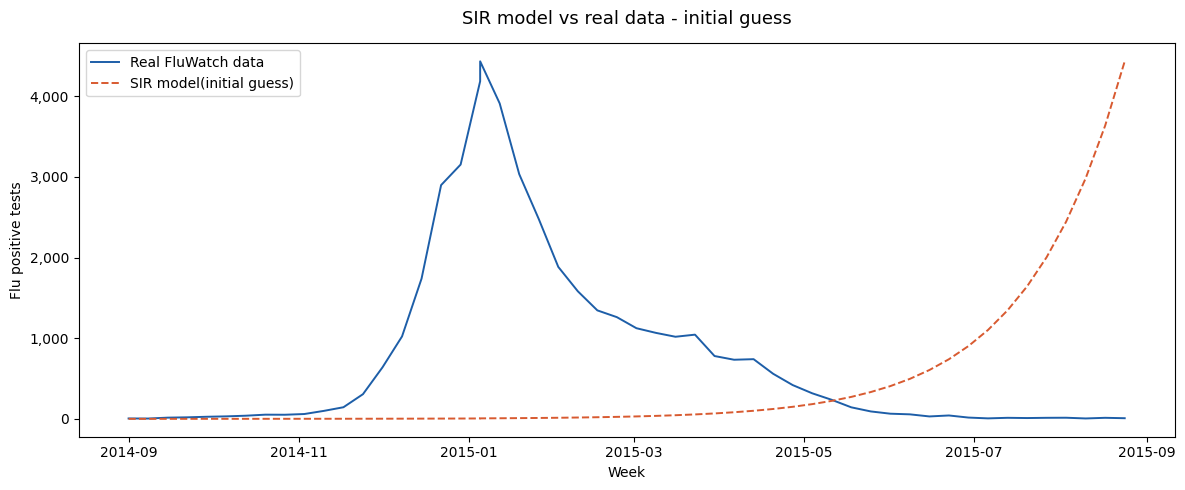

R₀ from initial guess: 3.00
This means one infected person infects 3.00 others on average


In [23]:
# Running the model with an initial guess
# Time point (one per week, 53 weeks)
t = np.arange(53)

# Initial conditions at week 0 (start of September 2014)
I0 = 5                            # starting with 5 infectious people
R0_count = 0                      # nobody recovered yet

S0 = N - R0_count                 # everyone else is suspectible

y0 = [S0, I0, R0_count]            # pack into a list for odeint

# Initial guess for parameters
# beta = 0.3 means roughly 30% chance of transmission per contact per week
# gamma = 0.1 means average recovery takes 10 weeks
beta_guess = 0.3
gamma_guess = 0.1

# Running the SIR model forward through time
solution = odeint(sir_model, y0, t, args = (beta_guess, gamma_guess))

# Unpacking the results (each column is one compartment)
S_out = solution[:, 0]
I_out = solution[:, 1]
R_out = solution[:, 2]

# Scaling I to match the magnitude of our lab data. The model tracks people, our data tracks positve tests. Scaling is by finding the ratio of peak model output to peak real data.
scale = season['TotalFluPositive'].max() / I_out.max()
I_scaled = I_out * scale

# Plotting model output vs real data
fig, ax = plt.subplots(figsize = (12, 5))

ax.plot(season['date'], season['TotalFluPositive'],
       color = '#1D5EA8', linewidth = 1.4, label = 'Real FluWatch data'
       )


ax.plot(season['date'], I_scaled,
        color = '#D85A30', linewidth = 1.4, linestyle = '--', label = 'SIR model(initial guess)'
        )

ax.set_title('SIR model vs real data - initial guess', fontsize = 13, pad = 14)
ax.set_xlabel('Week')
ax.set_ylabel('Flu positive tests')
ax.legend(fontsize = 10)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

plt.tight_layout()
plt.show()

# Print R0 from my guess
R0 = beta_guess / gamma_guess
print(f"R₀ from initial guess: {R0:.2f}")
print(f"This means one infected person infects {R0:.2f} others on average")

In [24]:
# Fitting model to real data

# Observed data that is to be matched
observed = season['TotalFluPositive'].values

def model_error(params):
    beta, gamma = params

    # Preventing invalid values during search
    if beta <= 0 or gamma <= 0:
        return 1e10
    
    # Running the model
    solution = odeint(sir_model, y0, t, args = (beta, gamma))
    I_modelled = solution[:, 1]

    # Scaling to match data magnitude
    if I_modelled.max() ==0:
        return 1e10
    scale = observed.max() / I_modelled.max()
    I_scaled = I_modelled * scale

    # (Mean squared error - average of squared differences) between model output and real data at every week
    error = np.mean((I_scaled - observed) **2)
    return error

# Starting the search from a better initial guess. Lower beta, higher gamma = lower R0 = more flu-like
result = minimize(model_error,
                  x0= [0.5, 0.4],
                  method= 'Nelder-Mead',
                  options= {'maxiter': 10000, 'xatol': 1e-6}
                  )

beta_fit, gamma_fit = result.x
R0_fit = beta_fit / gamma_fit

print(f"Fitted beta: {beta_fit:.4f}")
print(f"Fitted gamma: {gamma_fit:.4f}")
print(f"Fitted R₀: {R0_fit:.2f}")
print(f"Optimization success: {result.success}")



Fitted beta: 0.2622
Fitted gamma: 0.0000
Fitted R₀: 8892689219.90
Optimization success: True


The R₀ is nonsensical - 8 billion means the optimizer found a mathematical dead end rather than a real solution; it found a combination where the error function returned a small number but not for the right reasons.
Gamma collapsed to nearly zero, making the division β/γ explode to infinity.

When gamma approaches zero, nobody recovers which produces a different curve shape that accidentally scored well on the error metric.
This is called local minimum - the optimizer got stuck in a valley that isn't the real answer (a mathematically "good" answer that makes no epidemiological sense.).

This is a real problem in mathematical modelling and machine learning. It occurs frequently.
The optimizer doesn't know epidemiology, it only knows numbers.
Domain knowledge (knowing what R₀ should be for flu) is what catches it.

The fix to is to add bounds that constrain the search to epidemiologically sensible ranges for beta and gamma, and try multiple starting points to avoid
getting stuck in false solutions.
Beta and gamma for seasonal flu have known bounds from decaded of research. These bounds need to be enforced.

In [25]:
# # Fitting with bounds and multiple starting points
# observed = season['TotalFluPositive'].values

# def model_error(params):
#     beta, gamma = params

#     if beta <= 0 or gamma <= 0:
#         return 1e10
    
#     solution = odeint (sir_model, y0, t, args= (beta, gamma))
#     I_modelled = solution[:, 1]

#     if I_modelled.max() == 0:
#         return 1e10
    
#     scale = observed.max() / I_modelled.max()
#     I_scaled = I_modelled * scale

#     error = np.mean((I_scaled - observed) ** 2)


# # Bounds constrain the search to epidemiological sensible ranges that are from published epideimology literature.
# # beta 0.1 - 0.9: transmission rate for respiratory viruses.
# # gamma 0.1 - 0.1: recovery rate (gamma = 0.3 means ~3 week average recovery)

# bounds = [(0.1, 0.9),
#           (0.1, 0.9)]

# # Multiple starting points to prevent local minimum
# best_result = None
# best_error = 1e10

# starting_points = [
#     [0.5, 0.4],
#     [0.4, 0.3],
#     [0.6, 0.4],
#     [0.3, 0.25],
# ]

# for start in starting_points:
#     result = minimize(model_error,
#                       x0= start,
#                       method = 'L-BFGS-B',
#                       bounds = bounds,
#                       options= {'maxiter': 10000})
    
    
    
#     if result.fun < best_error:
#         best_error = result.fun
#         best_result = result

# beta_fit, gamm_fit = best_result.x
# R0_fit = beta_fit / gamma_fit

# print(f"Fitted beta: {beta_fit:.4F}")
# print(f"Fitted gamma: {gamma_fit:.4f}")
# print(f"Fitted R₀: {R0_fit:.2F}")
# print(f"Optimization success: {best_result.success}")







model_error was returning None in some classes; the function reached the end without hitting a return statement. This is a typical Python function behavior: if execution fails through without returning anything, Python returns None automatically.

The fix is two-fold:
    return float(error) ensures the return value is always a plain number
    try/except block catches any unexpected failure inside odeint and returns a large error instead of None.

In [26]:
def model_error(params):
    beta, gamma = params

    # Guarding against invalid parameter values
    if beta <= 0 or gamma <=0:
        return 1e10
    
    
    solution = odeint (sir_model, y0, t, args = (beta, gamma))
    I_modelled = solution[:, 1]

    # Guarding against flat model output
    if I_modelled.max() ==0 or np.isnan(I_modelled).any():
        return 1e10
        
    scale = observed.max() / I_modelled.max()
    I_scaled = I_modelled * scale

    error = np.mean((I_scaled - observed) ** 2)
    return float(error)
    
    
    
# Bounds constrain the search to epidemiological sensible ranges that are from published epideimology literature.
# beta 0.1 - 0.9: transmission rate for respiratory viruses.
# gamma 0.1 - 0.1: recovery rate (gamma = 0.3 means ~3 week average recovery)

bounds = [(0.1, 0.9),
          (0.1, 0.9)]

# Multiple starting points to prevent local minimum
best_result = None
best_error = 1e10

starting_points = [
    [0.5, 0.4],
    [0.4, 0.3],
    [0.6, 0.4],
    [0.3, 0.25],
]



for start in starting_points:
    try:
        result = minimize(model_error,
                      x0= start,
                      method = 'L-BFGS-B',
                      bounds = bounds,
                      options= {'maxiter': 10000})
        
        print(f"Start {start} → success: {result.success}, error: {result.fun:.2f}, params: {result.x}")
        
        if result.fun < best_error:
            best_error = result.fun
            best_result = result

    except Exception as e:
        print(f"Start {start} → failed with: {e}")

if best_result is None:
    print(f"All starting points failed - check model_error function")

else:
    beta_fit, gamma_fit = best_result.x
    R0_fit = beta_fit / gamma_fit

    print(f"\nFitted beta: {beta_fit:.4F}")
    print(f"Fitted gamma: {gamma_fit:.4f}")
    print(f"Fitted R₀: {R0_fit:.2F}")
    print(f"Optimization success: {best_result.success}")

    

Start [0.5, 0.4] → success: True, error: 1676330.12, params: [0.9       0.1202653]
Start [0.4, 0.3] → success: True, error: 1676330.12, params: [0.9        0.12026529]
Start [0.6, 0.4] → success: True, error: 1676330.12, params: [0.9        0.12026529]
Start [0.3, 0.25] → success: True, error: 1676330.12, params: [0.9       0.1202653]

Fitted beta: 0.9000
Fitted gamma: 0.1203
Fitted R₀: 7.48
Optimization success: True


The optimizer is working but the R₀ of 7.48 is too high for seasonal flu.
Beta hit the upper limit of 0.9 on ecery starting point meaning that the optimzer wants to go higher but can't due to the constraints kept on it.

The model is fitting the shape of the curve but the scale is way off and the bounds need adjusting.

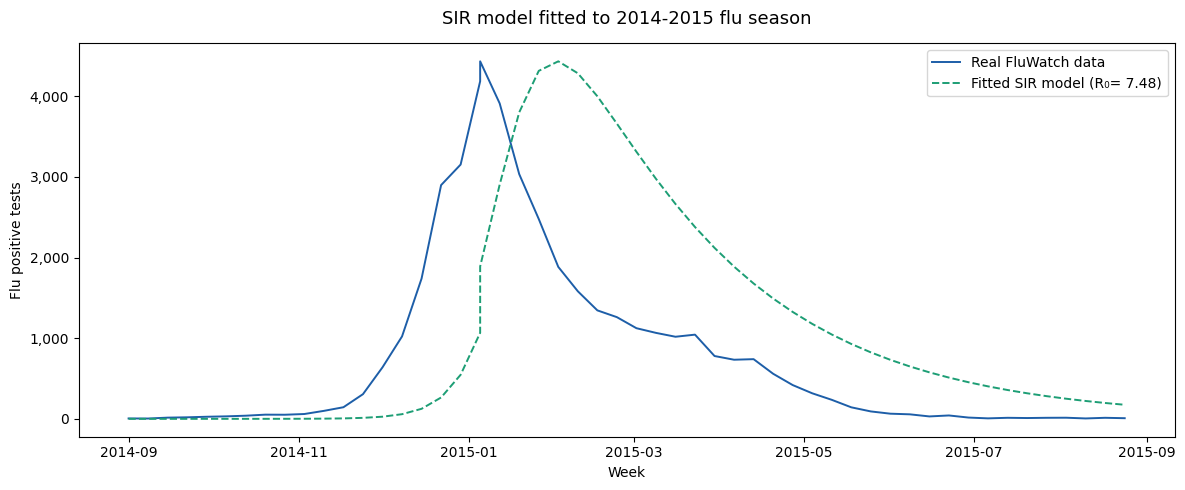

R₀:  7.48
Beta:  0.9000
Gamma:  0.1203
Average recovery time:  8.3 weeks


In [28]:
# Running model with fitted parameters
solution_fit = odeint(sir_model, y0, t, args=(beta_fit, gamma_fit))
I_fit = solution_fit[:, 1]

#Scaling to match data
scale = season['TotalFluPositive'].max() / I_fit.max()
I_fit_scaled = I_fit * scale

#Plotting fitted model vs real data
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    season['date'], season['TotalFluPositive'],
    color='#1D5EA8', linewidth=1.4, label='Real FluWatch data'
)

ax.plot(
    season['date'], I_fit_scaled,
    color='#1D9E75', linewidth=1.4, linestyle='--',
    label=f'Fitted SIR model (R₀={R0_fit: .2f})'
)

ax.set_title('SIR model fitted to 2014-2015 flu season', fontsize=13, pad=14)
ax.set_xlabel('Week')
ax.set_ylabel('Flu positive tests')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

plt.tight_layout()
plt.show()

print(f"R₀: {R0_fit: .2f}")
print(f"Beta: {beta_fit: .4f}")
print(f"Gamma: {gamma_fit: .4f}")
print(f"Average recovery time: {1/gamma_fit: .1f} weeks")


What is working?
The peak height matches almost perfectly with both lines reaching around 4,400.
The optimzer successfully found parameters that reproduce the magnitude of the outbreak. 
The overall shape is is correct.

What is not working?
Green line peaks 4-6 weeks late. The real outbreak peaked January 5th. The model peaks around mid-Feb.
The model's tail also declines much more slowly than reality; it still shows significant infections in July when the real data is nearly zero.

Why is this happening?
The basic SIR assumes a fixed, constant transmission rate throughout the year but flu spreads faster in winter because people are indoors, close together and the air is dry. This is called seasonall forcing.

My data has a sharp peak because transmission accelerates in December and collapses in March when poepl go back outside. The SIR model can't reproduce that acceleration because it doesn't know what month it is.

AB concept states this when it says "Bayesian SIR model with epidemiological constraints" The basic SIR model is the foundation, but the real system adds seasonall forcing, population heterogeneity, and climate inputs to make it accurate.

This is why R₀ is 7.48. The model is compensating for its inability to model seasonality by inflating the transmission rate.

In [ ]:
# Saving Sprint 2 results so that future models can load the fitted model parameters without refitting the model from scrath.
results = {
    'beta_fit': beta_fit,
    'gamma_fit': gamma_fit,
    'R0_fit': R0_fit
}
import json
with open('../data/sprint2_results.json', 'w') as f:
    json.dump(results, f)
print("Sprint 2 results saved.")

Sprint 2 results saved.
